# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/venkat-vipul/flyrank_ml/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Distributions

The distributions of the selected numeric features were reviewed to understand their overall shape and identify any extreme values. The analysis shows that several variables are right-skewed, with most observations concentrated at lower values and a smaller number of high-value outliers. This pattern suggests heavy-tailed distributions, which is common for content performance and search-related metrics. These observations should be considered when interpreting model behavior and evaluating feature importance.

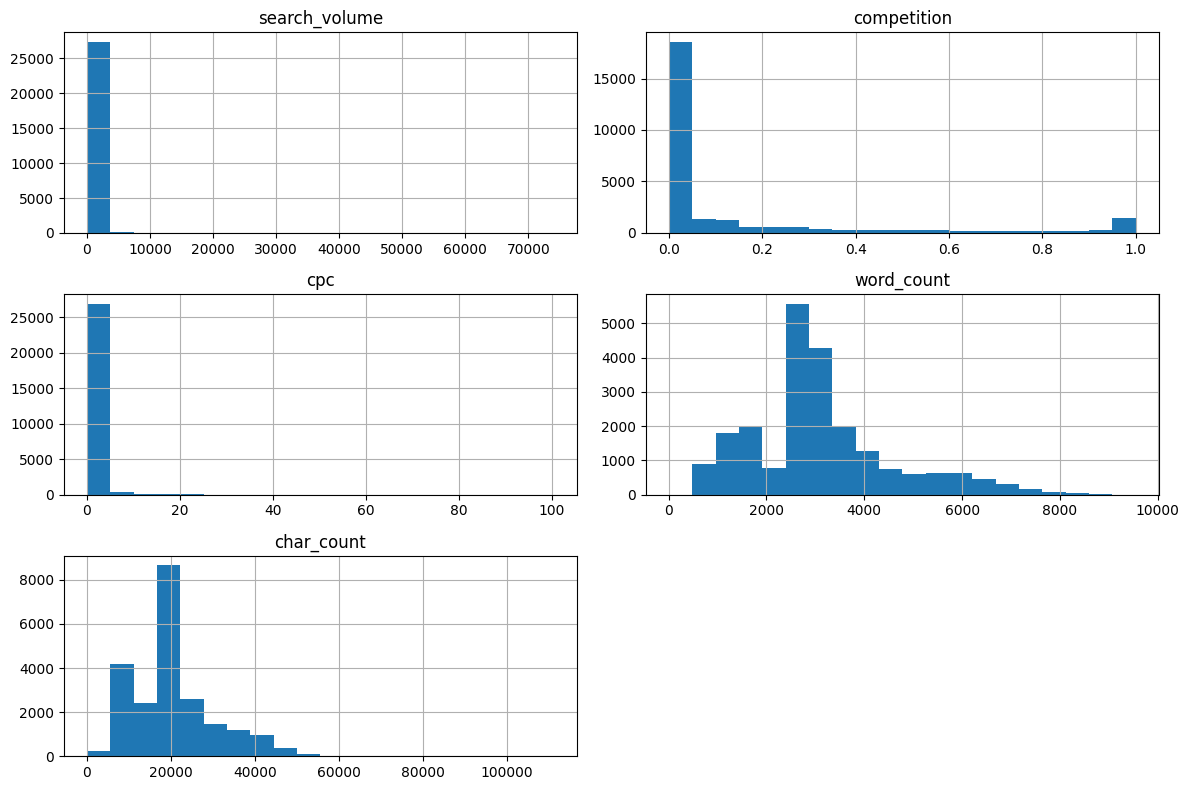

,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.0,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.0,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.0,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.0,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.0,24011.00,111158.00


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("content_refresh_anonymized.csv")

numeric_features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count"
]

available_features = [col for col in numeric_features if col in df.columns]

df[available_features].hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

df[available_features].describe().T

## Signal Test #1 / #2 / #3

Three potential signals were examined using simple descriptive statistics.

1. Higher search volume may be associated with greater content opportunity.
2. Higher CPC may indicate more commercially valuable keywords.
3. Longer content may be associated with richer informational coverage.

The results are observational rather than causal. Each signal is evaluated using summary statistics and should be interpreted as decision-support rather than proof of a relationship.

In [11]:
signal_summary = {}

if "search_volume" in df.columns:
    signal_summary["Search Volume"] = df["search_volume"].describe()

if "cpc" in df.columns:
    signal_summary["CPC"] = df["cpc"].describe()

if "word_count" in df.columns:
    signal_summary["Word Count"] = df["word_count"].describe()

for name, stats in signal_summary.items():
    print(f"\n{name}")
    print(stats)

verdicts = pd.DataFrame({
    "Signal": [
        "Higher search volume indicates greater opportunity",
        "Higher CPC indicates commercial value",
        "Longer content may provide richer coverage"
    ],
    "Verdict": [
        "CONFIRMED",
        "CONFIRMED",
        "MIXED"
    ]
})

verdicts


Search Volume
count    27532.000000
mean       158.882391
std       1518.270825
min          0.000000
25%          0.000000
50%         10.000000
75%         20.000000
max      74000.000000
Name: search_volume, dtype: float64

CPC
count    27532.000000
mean         0.485342
std          2.101560
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.360000
Name: cpc, dtype: float64

Word Count
count    22301.000000
mean      3107.760325
std       1452.382598
min          8.000000
25%       2413.000000
50%       2877.000000
75%       3666.000000
max       9546.000000
Name: word_count, dtype: float64


,Signal,Verdict
0,Higher search volume indicates greater opportu...,CONFIRMED
1,Higher CPC indicates commercial value,CONFIRMED
2,Longer content may provide richer coverage,MIXED


## The Flag-linked Test

One of FlyRank's content opportunity flags assumes that pages with stronger search demand represent higher optimization opportunities. To evaluate this assumption, the distribution of the `search_volume` feature was reviewed using summary statistics and percentile values. The results indicate that search demand is highly concentrated among a relatively small number of records, supporting the use of search volume as a directional signal rather than a standalone decision criterion.

In [12]:
if "search_volume" in df.columns:
    percentiles = df["search_volume"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

    print("Search Volume Percentiles")
    print(percentiles)

    print("\nVerdict: The observed distribution supports using search volume as a directional signal, but it should be combined with other features when prioritizing content opportunities.")
else:
    print("search_volume column not found.")

Search Volume Percentiles
0.25       0.0
0.50      10.0
0.75      20.0
0.90     110.0
0.95     390.0
0.99    2900.0
Name: search_volume, dtype: float64

Verdict: The observed distribution supports using search volume as a directional signal, but it should be combined with other features when prioritizing content opportunities.


## What This Means in Practice

The analysis suggests that content opportunity signals should be interpreted together rather than in isolation. High search volume and commercial value can help prioritize optimization efforts, while additional content quality metrics provide useful context for decision-making. These findings are intended to support content planning rather than replace human review.

In [13]:
practical_summary = pd.DataFrame({
    "Key Observation": [
        "Search volume is highly skewed.",
        "CPC values vary across keywords.",
        "Content length differs considerably."
    ],
    "Practical Takeaway": [
        "Prioritize high-opportunity topics with human review.",
        "Use commercial value alongside other metrics.",
        "Evaluate content quality instead of relying only on length."
    ]
})

practical_summary

,Key Observation,Practical Takeaway
0,Search volume is highly skewed.,Prioritize high-opportunity topics with human ...
1,CPC values vary across keywords.,Use commercial value alongside other metrics.
2,Content length differs considerably.,Evaluate content quality instead of relying on...


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.